In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [7]:
df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

[*********************100%***********************]  1 of 1 completed


In [8]:
#view data
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


In [9]:
#check data types
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [11]:
#check null values
df.isnull()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,False,False,False,False,False
2020-01-03,False,False,False,False,False
2020-01-06,False,False,False,False,False
2020-01-07,False,False,False,False,False
2020-01-08,False,False,False,False,False
...,...,...,...,...,...
2024-12-24,False,False,False,False,False
2024-12-26,False,False,False,False,False


In [12]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [13]:
df.dropna()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200
...,...,...,...,...,...
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100


In [15]:
df.dropna(inplace=True)

In [17]:
#total rows and columns
df.shape

(1258, 5)

In [18]:
#highest stock price
df['High'].max()

Ticker
AAPL    258.44874
dtype: float64

In [19]:
#Lowest stock price
df['Low'].min()


Ticker
AAPL    51.3248
dtype: float64

In [20]:
#avg closing price
df['Close'].mean()

Ticker
AAPL    151.377786
dtype: float64

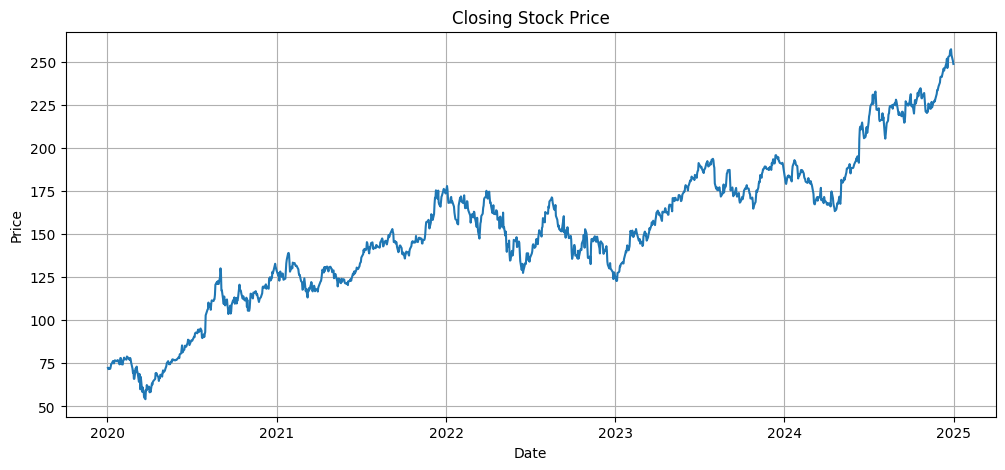

In [21]:
#stock trend graph
plt.figure(figsize=(12,5))

plt.plot(df['Close'])

plt.title("Closing Stock Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.grid()

plt.show()

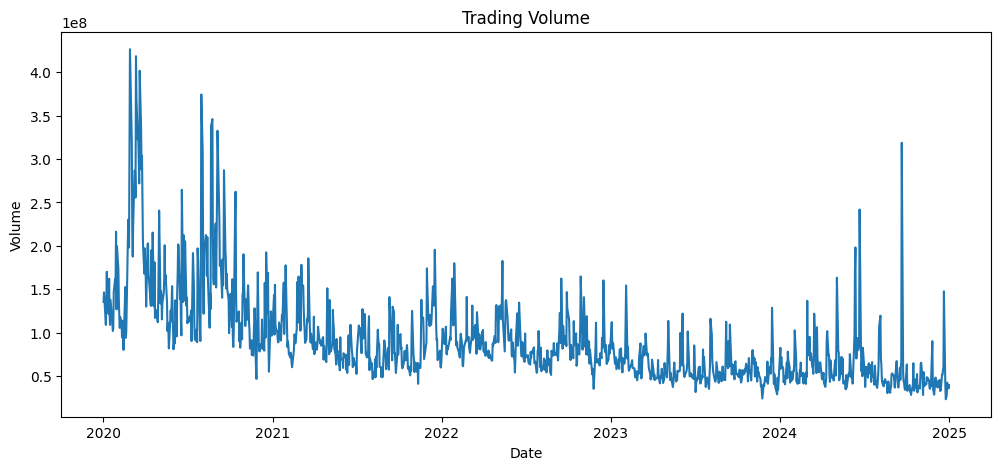

In [22]:
#volume analysis
plt.figure(figsize=(12,5))

plt.plot(df['Volume'])

plt.title("Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.show()

In [25]:
#moving avg
df['MA_30'] = df['Close'].rolling(window=30).mean()

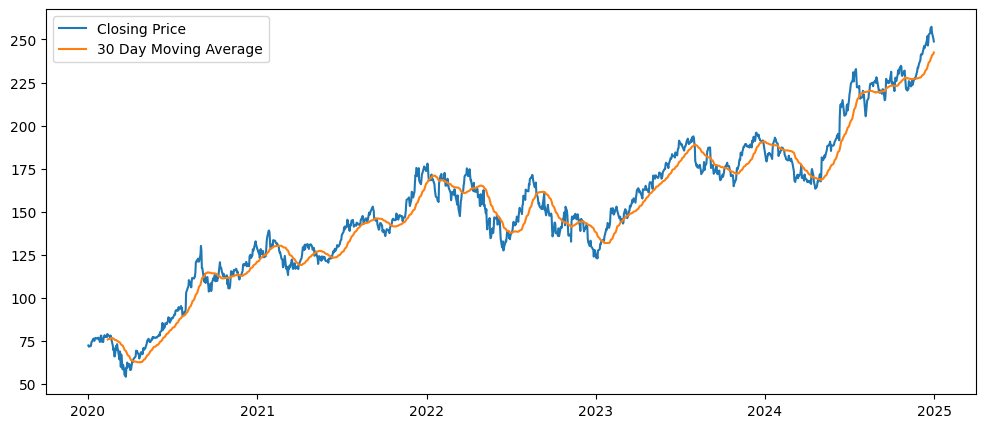

In [26]:
#moving avg graph
plt.figure(figsize=(12,5))

plt.plot(df['Close'], label='Closing Price')

plt.plot(df['MA_30'], label='30 Day Moving Average')

plt.legend()

plt.show()

In [27]:
#daily return
df['Daily_Return'] = df['Close'].pct_change()

print(df['Daily_Return'].head())

Date
2020-01-02         NaN
2020-01-03   -0.009722
2020-01-06    0.007968
2020-01-07   -0.004703
2020-01-08    0.016086
Name: Daily_Return, dtype: float64


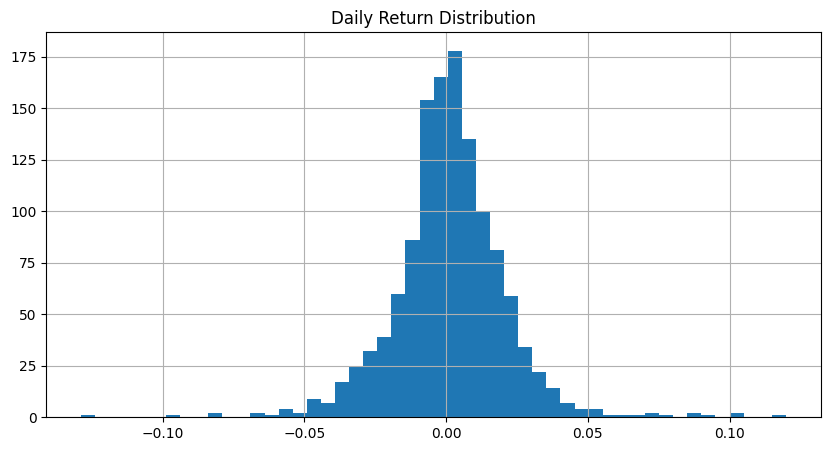

In [28]:
#histogram of returns
plt.figure(figsize=(10,5))

df['Daily_Return'].hist(bins=50)

plt.title("Daily Return Distribution")

plt.show()

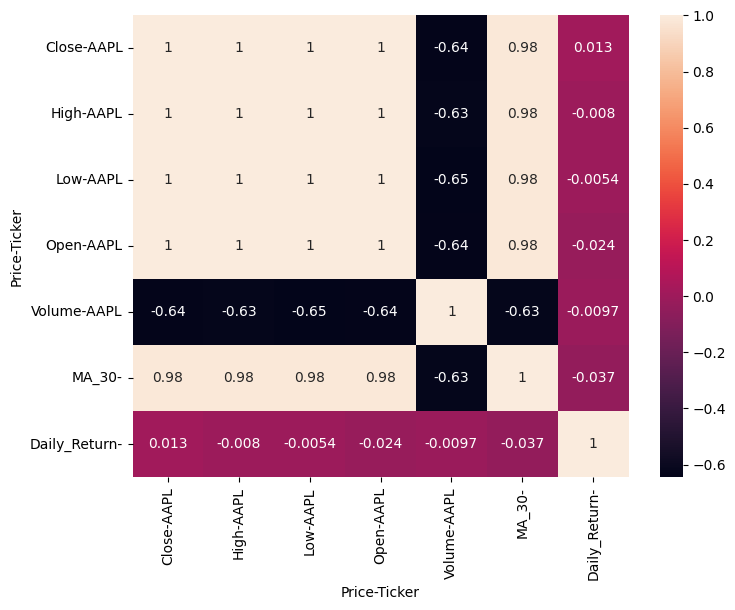

In [33]:
#Correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

In [34]:
#IMPORT MACHINE LEARNING LIBRARIES
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [35]:
#PREPARE DATA FOR FORECASTING
df['Prediction'] = df[['Close']].shift(-30)

print(df.head())

Price           Close       High        Low       Open     Volume MA_30  \
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL         
Date                                                                      
2020-01-02  72.333855  72.394063  71.091161  71.344032  135480400   NaN   
2020-01-03  71.630638  72.389257  71.406666  71.563205  146322800   NaN   
2020-01-06  72.201416  72.239950  70.503554  70.754021  118387200   NaN   
2020-01-07  71.861847  72.466330  71.642689  72.211049  108872000   NaN   
2020-01-08  73.017838  73.318877  71.565621  71.565621  132079200   NaN   

Price      Daily_Return Prediction  
Ticker                              
Date                                
2020-01-02          NaN  78.444061  
2020-01-03    -0.009722  77.007721  
2020-01-06     0.007968  78.123016  
2020-01-07    -0.004703  77.321510  
2020-01-08     0.016086  75.571358  


In [36]:
#create input and output
X = np.array(df[['Close']])

X = X[:-30]

y = np.array(df['Prediction'])

y = y[:-30]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
#create model
model = LinearRegression()

In [39]:
#train model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.97]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.387
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1246.21]


In [40]:
#check model accuracy
accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.895980517405307


In [41]:
#FUTURE PREDICTION
x_future = df[['Close']].tail(30)

x_future = np.array(x_future)

future_prediction = model.predict(x_future)

print(future_prediction)

[228.02971606 228.27900645 228.96942156 228.50915463 229.80362407
 232.68025553 234.78019944 234.65555425 236.95684469 239.12390411
 242.05806526 242.40328754 242.43204502 242.24025486 245.98946159
 246.96752512 245.7401712  247.14972945 247.31271795 250.10304753
 252.44272545 247.23601662 248.90446581 253.41117371 254.15908906
 256.96860501 257.75484893 254.46592385 251.21532736 249.50854958]


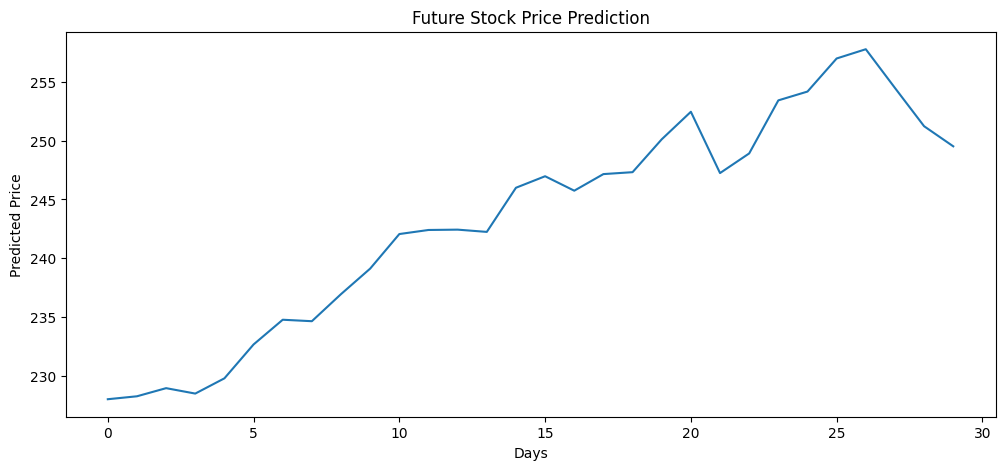

In [42]:
#VISUALIZE FORECAST
plt.figure(figsize=(12,5))

plt.plot(future_prediction)

plt.title("Future Stock Price Prediction")

plt.xlabel("Days")

plt.ylabel("Predicted Price")

plt.show()

In [ ]:
#final business insights
1.Stock price showed upward trend.
2.Trading volume increased during growth periods.
3.Moving average helped identify stable trends.
4.Forecasting model predicted future stock movement.
5.Daily returns showed market volatility.